In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0. Setting
# -----------------------------
torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# -----------------------------
# 1. Problem setting
# -----------------------------
n_grid = 64
n_train = 512
n_test = 128

nu = 0.01
T = 0.5   # longer time, so u(T,x) is visibly different from u0(x)


# -----------------------------
# 2. Generate random initial conditions
# -----------------------------
def generate_random_functions(batch_size, n_grid, max_mode=5):
    """
    Generate smooth random initial conditions u0(x).
    Shape: (batch_size, n_grid)
    """
    x = torch.linspace(0, 1, n_grid, device=device)
    u = torch.zeros(batch_size, n_grid, device=device)

    for k in range(1, max_mode + 1):
        a = torch.randn(batch_size, 1, device=device)
        b = torch.randn(batch_size, 1, device=device)

        u += a * torch.sin(2 * np.pi * k * x)
        u += b * torch.cos(2 * np.pi * k * x)

    return u


# -----------------------------
# 3. Heat equation solver by FFT
# -----------------------------
def heat_solution_fft(u0, nu=0.01, T=0.5):
    """
    Solve periodic heat equation:
        u_t = nu u_xx

    Input:
        u0: initial condition, shape (batch, n_grid)

    Output:
        uT: solution at time T, shape (batch, n_grid)
    """
    batch_size, n = u0.shape

    # Fourier transform
    u0_hat = torch.fft.rfft(u0, dim=-1)

    # Fourier frequencies
    k = torch.fft.rfftfreq(n, d=1.0 / n).to(device)

    # Heat equation decay in Fourier domain
    decay = torch.exp(-nu * (2 * np.pi * k) ** 2 * T)

    # Apply decay and inverse Fourier transform
    uT_hat = u0_hat * decay
    uT = torch.fft.irfft(uT_hat, n=n, dim=-1)

    return uT


# -----------------------------
# 4. Prepare training and test data
# -----------------------------
u0_train = generate_random_functions(n_train, n_grid)
uT_train = heat_solution_fft(u0_train, nu=nu, T=T)

u0_test = generate_random_functions(n_test, n_grid)
uT_test = heat_solution_fft(u0_test, nu=nu, T=T)

# Add channel dimension: (batch, n_grid, 1)
u0_train = u0_train[..., None]
uT_train = uT_train[..., None]

u0_test = u0_test[..., None]
uT_test = uT_test[..., None]

print("u0_train shape:", u0_train.shape)
print("uT_train shape:", uT_train.shape)

device: cuda
u0_train shape: torch.Size([512, 64, 1])
uT_train shape: torch.Size([512, 64, 1])


## Visualize the operator-learning dataset

Before training GNO, let us check what the dataset looks like.

Each training example is a pair:

$$
u_0^{(i)}(x) \mapsto u^{(i)}(T,x).
$$

The left figure shows the input initial condition, and the right figure shows the corresponding heat-equation solution.

This is important because GNO is not learning only one solution.  
It learns a map from many different input functions to their corresponding solution functions.

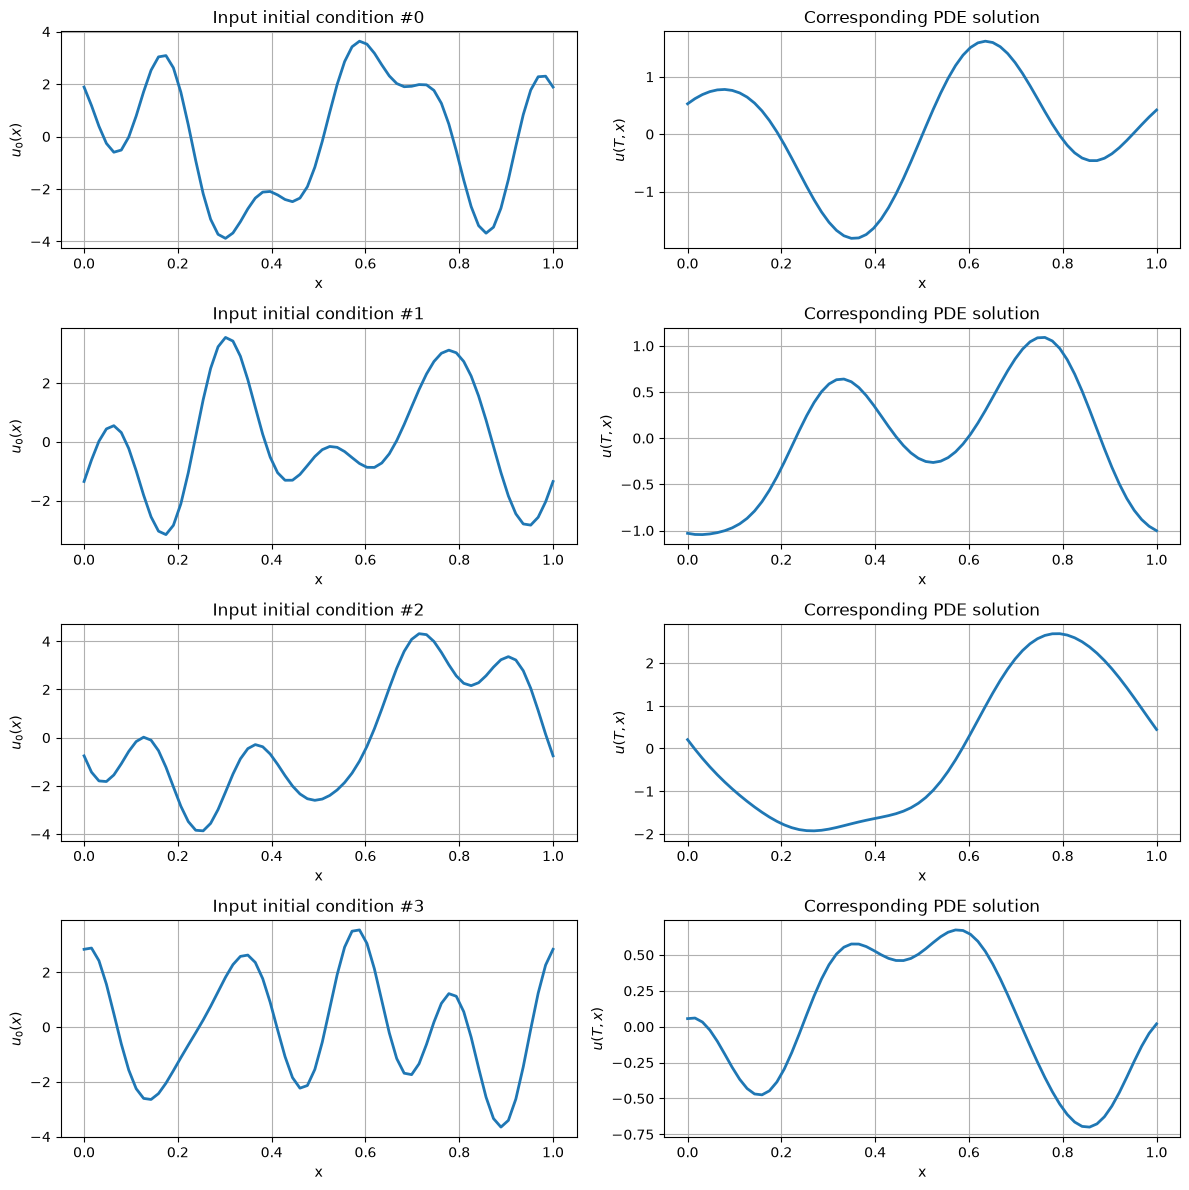

In [2]:
# -----------------------------
# Visualize input-output pairs
# -----------------------------
def plot_dataset_examples(u0, uT, sample_ids=[0, 1, 2, 3]):
    """
    Visualize several examples of the operator-learning dataset.

    Each row shows:
        input function  u0(x)
        output function u(T,x)

    This helps us see that different initial conditions
    produce different corresponding PDE solutions.
    """
    x_cpu = torch.linspace(0, 1, u0.shape[1]).cpu().numpy()

    n_samples = len(sample_ids)
    plt.figure(figsize=(12, 3 * n_samples))

    for row, sample_id in enumerate(sample_ids):
        # Input function u0(x)
        u0_cpu = u0[sample_id, :, 0].detach().cpu().numpy()

        # Corresponding solution u(T,x)
        uT_cpu = uT[sample_id, :, 0].detach().cpu().numpy()

        # Plot input
        plt.subplot(n_samples, 2, 2 * row + 1)
        plt.plot(x_cpu, u0_cpu, linewidth=2)
        plt.xlabel("x")
        plt.ylabel(r"$u_0(x)$")
        plt.title(f"Input initial condition #{sample_id}")
        plt.grid(True)

        # Plot output
        plt.subplot(n_samples, 2, 2 * row + 2)
        plt.plot(x_cpu, uT_cpu, linewidth=2)
        plt.xlabel("x")
        plt.ylabel(r"$u(T,x)$")
        plt.title("Corresponding PDE solution")
        plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_dataset_examples(
    u0_train,
    uT_train,
    sample_ids=[0, 1, 2, 3]
)

## Why this is useful before GNO

GNO approximates an integral operator by message passing:

$$
v_{l+1}(x_i)
=
\sigma\left(
Wv_l(x_i)
+
\sum_j \kappa_\phi(x_i,x_j)v_l(x_j)
\right).
$$

The dataset visualization above shows what this operator should learn:

$$
u_0(x) \longrightarrow u(T,x).
$$

So the GNO model should take the whole input function \(u_0(x)\), mix information across grid points through graph-style interactions, and output the corresponding solution function.

In [3]:
# -----------------------------
# 5. GNO block
# -----------------------------
class GNOBlock1D(nn.Module):
    def __init__(self, width):
        super().__init__()

        # Local transformation W v(x)
        self.local = nn.Linear(width, width)

        # Learnable kernel kappa_phi(x_i, x_j)
        # Here we use x_i - x_j as the edge feature.
        self.kernel = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, width)
        )

        self.norm = nn.LayerNorm(width)

    def forward(self, v, grid):
        """
        v:    hidden function values, shape (batch, n_grid, width)
        grid: spatial grid, shape (n_grid,)
        """
        batch_size, n, width = v.shape

        xi = grid[None, :, None, None]  # (1, n, 1, 1)
        xj = grid[None, None, :, None]  # (1, 1, n, 1)

        # Edge feature between two grid points
        edge_feature = xi - xj          # (1, n, n, 1)

        # Kernel weight
        kernel_weight = self.kernel(edge_feature)  # (1, n, n, width)

        # Source value v(x_j)
        v_j = v[:, None, :, :]          # (batch, 1, n, width)

        # Message from x_j to x_i
        message = kernel_weight * v_j   # (batch, n, n, width)

        # Approximate integral by average over source points
        integral_approx = message.mean(dim=2)

        # Local + nonlocal update
        out = self.local(v) + integral_approx
        out = self.norm(out)

        return F.gelu(out)


# -----------------------------
# 6. Simple GNO model
# -----------------------------
class SimpleGNO1D(nn.Module):
    def __init__(self, width=32, depth=4):
        super().__init__()

        # Input channels: u0(x), x
        self.lift = nn.Linear(2, width)

        self.blocks = nn.ModuleList([
            GNOBlock1D(width) for _ in range(depth)
        ])

        self.project = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, u0):
        """
        u0: input function, shape (batch, n_grid, 1)
        """
        batch_size, n, _ = u0.shape

        grid = torch.linspace(0, 1, n, device=u0.device)
        grid_input = grid[None, :, None].repeat(batch_size, 1, 1)

        # Lifting
        v = torch.cat([u0, grid_input], dim=-1)
        v = self.lift(v)

        # Operator layers
        for block in self.blocks:
            v = block(v, grid)

        # Projection
        out = self.project(v)

        return out

In [6]:
# -----------------------------
# 7. Training function
# -----------------------------
def relative_l2_error(pred, true):
    """
    pred, true: shape (batch, n_grid, 1)
    """
    pred = pred.reshape(pred.shape[0], -1)
    true = true.reshape(true.shape[0], -1)

    return torch.norm(pred - true, dim=1) / torch.norm(true, dim=1)


def train_model(model, train_x, train_y, test_x, test_y, epochs=300, batch_size=64):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()

    n_train = train_x.shape[0]

    train_loss_history = []
    test_loss_history = []
    test_rel_l2_history = []

    for epoch in range(epochs):
        model.train()

        perm = torch.randperm(n_train, device=device)
        total_loss = 0.0

        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]

            batch_x = train_x[idx]
            batch_y = train_y[idx]

            pred = model(batch_x)
            loss = mse(pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # evaluation
        model.eval()
        with torch.no_grad():
            test_pred = model(test_x)
            test_loss = mse(test_pred, test_y).item()
            test_rel_l2 = relative_l2_error(test_pred, test_y).mean().item()

        train_loss_history.append(total_loss)
        test_loss_history.append(test_loss)
        test_rel_l2_history.append(test_rel_l2)

        if epoch % 50 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train loss: {total_loss:.6f} | "
                f"test MSE: {test_loss:.6f} | "
                f"test rel L2: {test_rel_l2:.6f}"
            )

    return train_loss_history, test_loss_history, test_rel_l2_history

In [7]:
# -----------------------------
# 8. Train GNO
# -----------------------------
gno = SimpleGNO1D(width=32, depth=4).to(device)

train_loss_history, test_loss_history, test_rel_l2_history = train_model(
    gno,
    u0_train,
    uT_train,
    u0_test,
    uT_test,
    epochs=500,
    batch_size=64
)

Epoch    0 | train loss: 5.949314 | test MSE: 0.569630 | test rel L2: 0.832378
Epoch   50 | train loss: 1.357152 | test MSE: 0.155353 | test rel L2: 0.481105
Epoch  100 | train loss: 0.669181 | test MSE: 0.084532 | test rel L2: 0.357979
Epoch  150 | train loss: 0.401230 | test MSE: 0.053598 | test rel L2: 0.282172
Epoch  200 | train loss: 0.281025 | test MSE: 0.046490 | test rel L2: 0.271125
Epoch  250 | train loss: 0.230893 | test MSE: 0.031868 | test rel L2: 0.218313
Epoch  300 | train loss: 0.254655 | test MSE: 0.029965 | test rel L2: 0.214469
Epoch  350 | train loss: 0.173790 | test MSE: 0.035270 | test rel L2: 0.239637
Epoch  400 | train loss: 0.158411 | test MSE: 0.023581 | test rel L2: 0.191419
Epoch  450 | train loss: 0.160042 | test MSE: 0.020615 | test rel L2: 0.178538


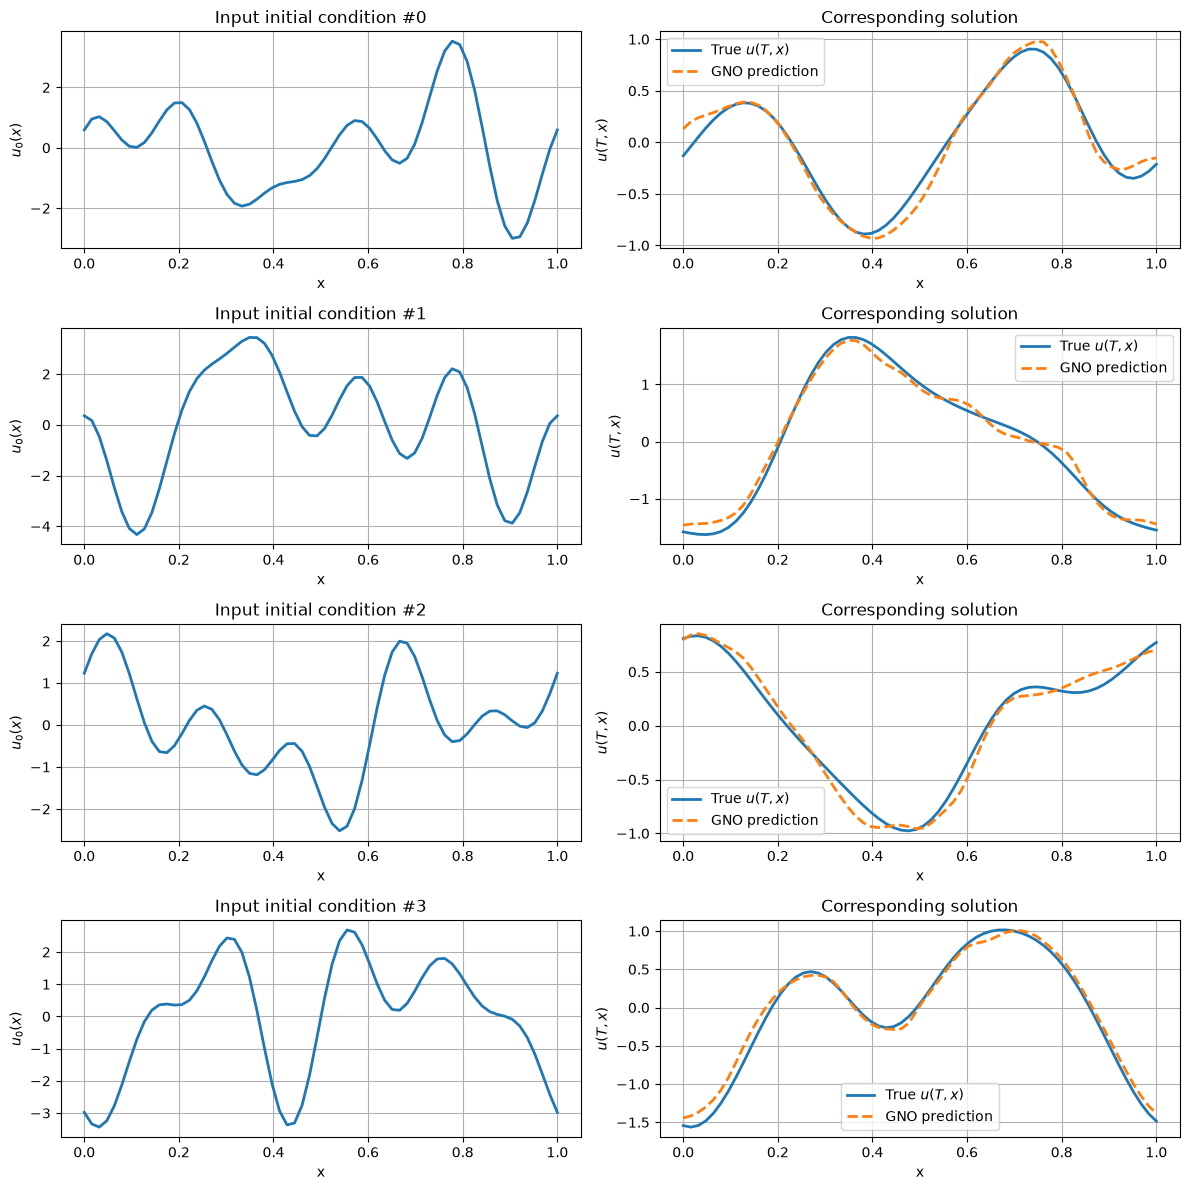

In [9]:
# -----------------------------
# 10. Visualize different initial conditions
# -----------------------------
def plot_multiple_operator_results(model, test_x, test_y, sample_ids=[0, 1, 2, 3], name="GNO"):
    """
    Show that different initial conditions produce different solutions.

        u0^{(i)}(x) --> u^{(i)}(T,x)

    test_x: shape (N, n_grid, 1)
    test_y: shape (N, n_grid, 1)
    """
    model.eval()

    n_samples = len(sample_ids)
    x_cpu = torch.linspace(0, 1, test_x.shape[1]).cpu().numpy()

    plt.figure(figsize=(12, 3 * n_samples))

    for row, sample_id in enumerate(sample_ids):
        with torch.no_grad():
            pred = model(test_x[sample_id:sample_id + 1])

        u0 = test_x[sample_id, :, 0].detach().cpu().numpy()
        true_uT = test_y[sample_id, :, 0].detach().cpu().numpy()
        pred_uT = pred[0, :, 0].detach().cpu().numpy()

        # Left: input function
        plt.subplot(n_samples, 2, 2 * row + 1)
        plt.plot(x_cpu, u0, linewidth=2)
        plt.xlabel("x")
        plt.ylabel(r"$u_0(x)$")
        plt.title(f"Input initial condition #{sample_id}")
        plt.grid(True)

        # Right: corresponding solution
        plt.subplot(n_samples, 2, 2 * row + 2)
        plt.plot(x_cpu, true_uT, "-", linewidth=2, label=r"True $u(T,x)$")
        plt.plot(x_cpu, pred_uT, "--", linewidth=2, label=f"{name} prediction")
        plt.xlabel("x")
        plt.ylabel(r"$u(T,x)$")
        plt.title("Corresponding solution")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_multiple_operator_results(
    gno,
    u0_test,
    uT_test,
    sample_ids=[0, 1, 2, 3],
    name="GNO"
)